# Data Exploration
Explore the GuitarSet dataset: inspect JAMS annotations, verify audio files, and identify monophonic segments suitable for training.

In [1]:
import jams
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from pathlib import Path

In [10]:
ANNOTATION_DIR = Path('../data/guitarset/annotation')
AUDIO_DIR = Path('../data/guitarset/audio')

annotation_files = sorted(ANNOTATION_DIR.glob('*.jams'))
print(f'Found {len(annotation_files)} annotation files')

Found 360 annotation files


## Inspect a single JAMS file

In [11]:
jam = jams.load(str(annotation_files[0]))
print(jam)

{
  "annotations": [
    {
      "annotation_metadata": {
        "curator": {
          "name": "",
          "email": ""
        },
        "annotator": {},
        "version": "",
        "corpus": "",
        "annotation_tools": "",
        "annotation_rules": "",
        "validation": "",
        "data_source": "0"
      },
      "namespace": "pitch_contour",
      "data": {
        "time": [
          7.463079364999999,
          7.468884353000021,
          7.474689342000033,
          7.480494331000045,
          7.486299319000068,
          7.49210430800008,
          7.497909297000092,
          7.503714285000001,
          7.509519274000013,
          7.515324263000025,
          7.521129251000048,
          7.52693424000006,
          7.532739229000072,
          7.538544217000094,
          7.544349205999993,
          7.550154195000005,
          7.555959183000027,
          7.561764172000039,
          7.567569160000062,
          7.573374149000074,
          7.5791791380

## Check note annotations per string

In [12]:
note_data = jam.search(namespace='note_midi')
print(f'Found {len(note_data)} string tracks')
for i, track in enumerate(note_data):
    print(f'String {i}: {len(track.data)} notes')

Found 6 string tracks
String 0: 7 notes
String 1: 23 notes
String 2: 33 notes
String 3: 36 notes
String 4: 25 notes
String 5: 9 notes


## Visualize note activity across strings

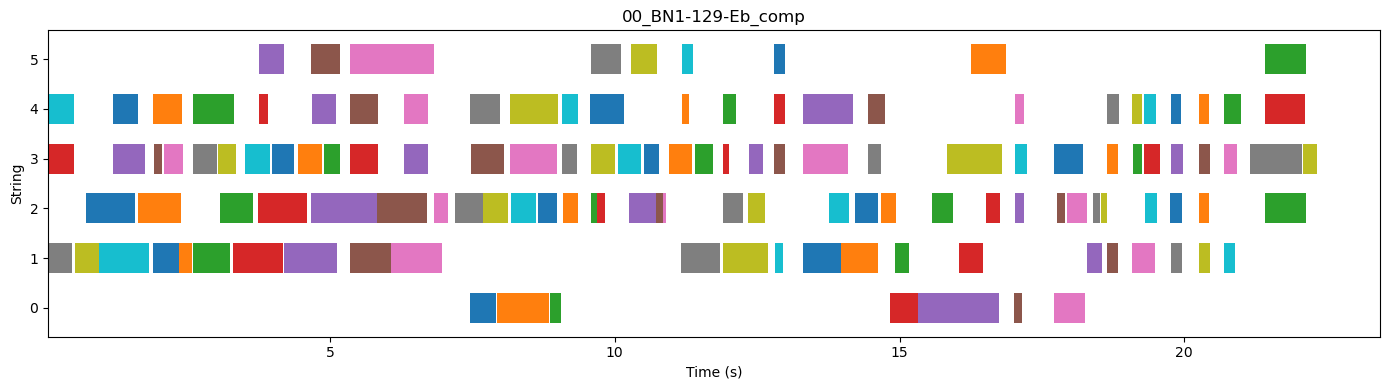

In [16]:
fig, ax = plt.subplots(figsize=(14, 4))
for i, track in enumerate(note_data):
    for obs in track.data:
        ax.barh(i, obs.duration, left=obs.time, height=0.6)
ax.set_xlabel('Time (s)')
ax.set_ylabel('String')
ax.set_title(annotation_files[0].stem)
plt.tight_layout()
plt.show()

## Identify monophonic segments

In [18]:
def count_simultaneous_strings(jam, resolution=0.01):
    """Return a time series of how many strings are active at each timestep."""
    note_data = jam.search(namespace='note_midi')
    duration = jam.file_metadata.duration
    times = np.arange(0, duration, resolution)
    active = np.zeros(len(times), dtype=int)
    for track in note_data:
        for obs in track.data:
            onset = obs.time
            offset = onset + obs.duration
            mask = (times >= onset) & (times < offset)
            active[mask] += 1
    return times, active

times, active = count_simultaneous_strings(jam)
mono_ratio = np.mean(active <= 1)
print(f'Monophonic (0-1 strings active): {mono_ratio:.1%} of the file')

Monophonic (0-1 strings active): 27.3% of the file


## Load and inspect the corresponding audio

Sample rate: 44100 Hz  |  Duration: 22.3s  |  Samples: 984506


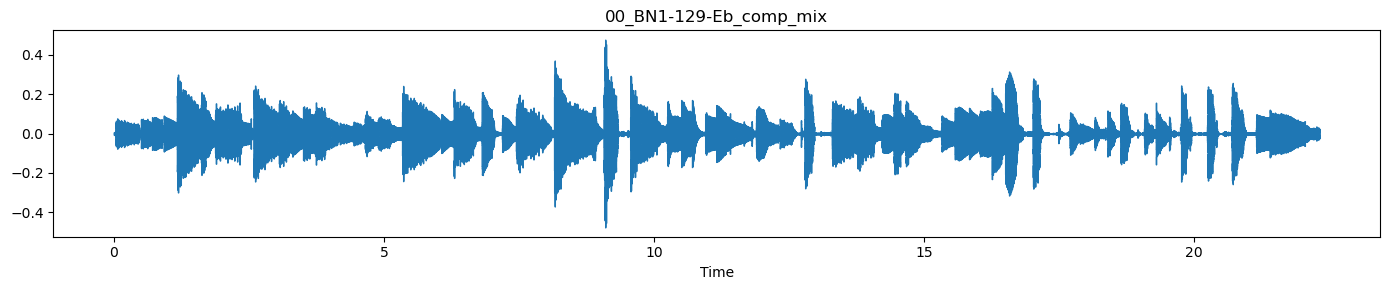

In [15]:
audio_file = AUDIO_DIR / (annotation_files[0].stem + '_mix.wav')
y, sr = librosa.load(str(audio_file), sr=None, mono=True)
print(f'Sample rate: {sr} Hz  |  Duration: {len(y)/sr:.1f}s  |  Samples: {len(y)}')

fig, ax = plt.subplots(figsize=(14, 3))
librosa.display.waveshow(y, sr=sr, ax=ax)
ax.set_title(audio_file.stem)
plt.tight_layout()
plt.show()

## Determine how much of the dataset is monophonic

Across 360 files:
  Mean monophonic ratio: 60.3%
  Files >90% monophonic: 133
  Files >50% monophonic: 199


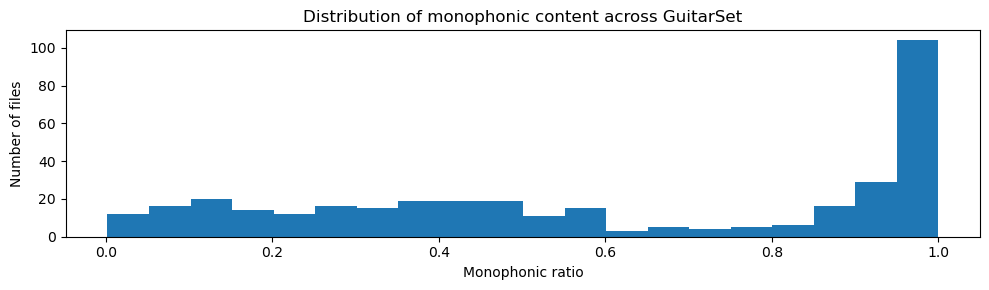

In [19]:
mono_ratios = []
for f in annotation_files:
    j = jams.load(str(f))
    _, active = count_simultaneous_strings(j)
    mono_ratios.append(np.mean(active <= 1))

mono_ratios = np.array(mono_ratios)
print(f'Across {len(annotation_files)} files:')
print(f'  Mean monophonic ratio: {mono_ratios.mean():.1%}')
print(f'  Files >90% monophonic: {(mono_ratios > 0.9).sum()}')
print(f'  Files >50% monophonic: {(mono_ratios > 0.5).sum()}')

plt.figure(figsize=(10, 3))
plt.hist(mono_ratios, bins=20)
plt.xlabel('Monophonic ratio')
plt.ylabel('Number of files')
plt.title('Distribution of monophonic content across GuitarSet')
plt.tight_layout()
plt.show()

## Visualize pitch distribution in dataset

Range: 40–81  (E2–A5)
Total notes: 62,476


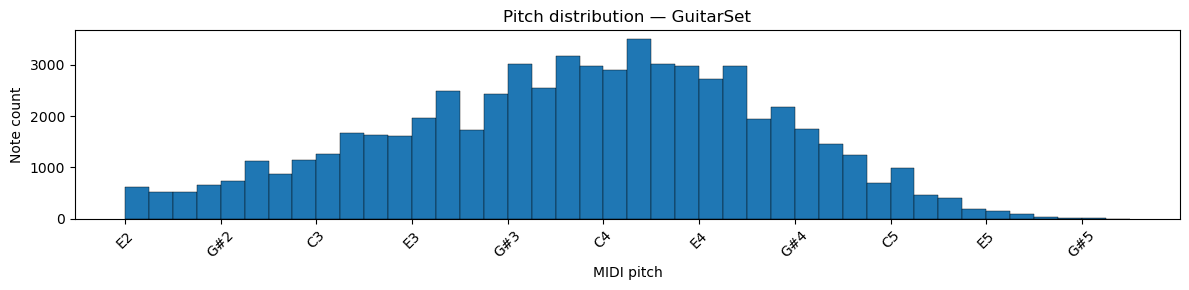

In [2]:
import pretty_midi

midi_dir = Path('../data/midi')
all_pitches = []

for midi_path in sorted(midi_dir.glob('*.mid')):
    pm = pretty_midi.PrettyMIDI(str(midi_path))
    for instrument in pm.instruments:
        for note in instrument.notes:
            all_pitches.append(note.pitch)

lo, hi = min(all_pitches), max(all_pitches)
print(f"Range: {lo}–{hi}  ({pretty_midi.note_number_to_name(lo)}–{pretty_midi.note_number_to_name(hi)})")
print(f"Total notes: {len(all_pitches):,}")

plt.figure(figsize=(12, 3))
plt.hist(all_pitches, bins=range(lo, hi + 2), edgecolor='black', linewidth=0.3)
plt.xticks(
    range(lo, hi + 1, 4),
    [pretty_midi.note_number_to_name(p) for p in range(lo, hi + 1, 4)],
    rotation=45,
)
plt.xlabel("MIDI pitch")
plt.ylabel("Note count")
plt.title("Pitch distribution — GuitarSet")
plt.tight_layout()
plt.show()


## Test JAMS parsing

In [23]:
import sys
sys.path.append('../src')

import importlib
import parse_jams
importlib.reload(parse_jams)
from parse_jams import parse_jams_to_midi

test_input = Path('../data/guitarset/annotation') / annotation_files[0].name
test_output = Path('../data/midi') / (annotation_files[0].stem + '.mid')

parse_jams_to_midi(test_input, test_output)
print(f'Created: {test_output}')
print(f'File exists: {test_output.exists()}')

Created: ..\data\midi\00_BN1-129-Eb_comp.mid
File exists: True
